In [1]:
import os
while "honeycomb.py" not in os.listdir():
    os.chdir("..")
    
    
from honeycomb import CSSHoneycomb
import numpy as np
import matplotlib.pyplot as plt

from qubit_containers import Vertex, Edge, Plaquette, BoundaryPlaquette

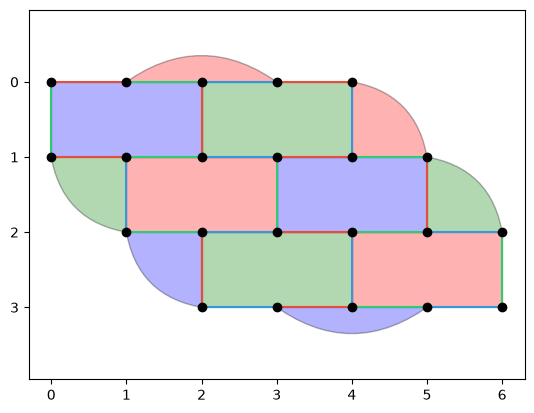

In [2]:
s = CSSHoneycomb()
s.plot_surface()

Edges

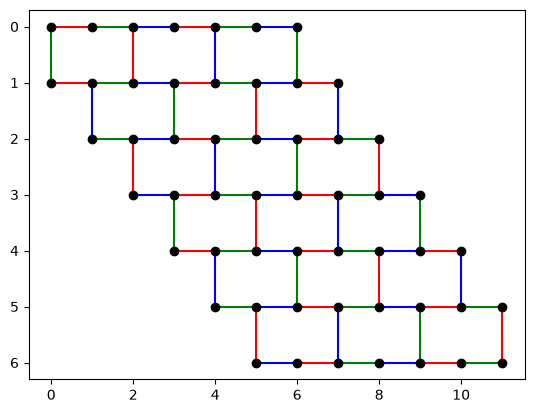

In [3]:
n_cols = 7
n_rows = 7

coords = []
vertices = []

key = 0

for y in range(n_rows):

    for x in range(n_cols + 1):

        # First row starts at 0 and has one fewer vertex
        if y == 0 and x == n_cols:
            continue

        # Last row also has one fewer vertex
        if y == n_rows - 1 and x == n_cols:
            continue

        xpos = x + y - 1 if y > 0 else x

        v = Vertex(key, (xpos, y))

        vertices.append(v)
        coords.append((xpos, y))

        key += 1

coords = np.array(coords)
edges = []
colours = {
    0 : 'red',
    1 : 'green',
    2 : 'blue'
}

i = 0
for j, v0 in enumerate(vertices):
    x, y = v0.pos

    if y < n_rows-1 and (x+y) % 2 == 0: # vert edge starts from top and works down
        
        v1 = vertices[j + n_cols]
        edges.append(Edge(key=i, v0=v0, v1=v1, colour=colours[(x+1)%3], ancilla_key=len(vertices)+i))
        i +=1
        

    if x < n_cols - 1 + y: # horizontal
        
        if y == n_rows - 1 and x == n_cols + n_rows - 3:
            continue
        
        v1 = vertices[j + 1]
        edges.append(Edge(key=i, v0=v0, v1=v1, colour=colours[x%3], ancilla_key=len(vertices)+i))
        i +=1

for edge in edges:
    (x0, y0), (x1, y1) = edge.get_coordinates()
    plt.plot((x0, x1), (y0, y1), c=edge.colour, zorder=0)
    plt.gca().yaxis.set_inverted(True)
    
plt.scatter(coords[:,0], coords[:,1], c="black", zorder=1)
plt.gca().yaxis.set_inverted(True)

plt.show()

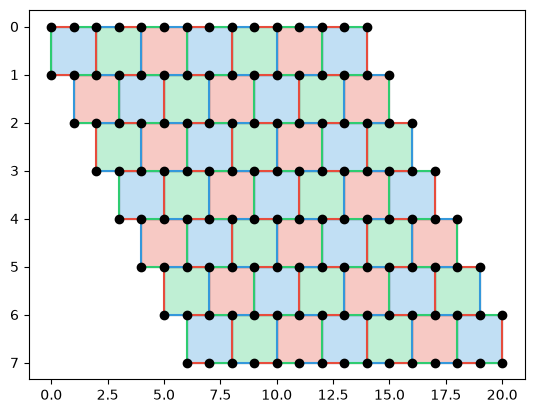

In [4]:
PALETTE = {
    'red' : '#e74c3c', 
    'green' : '#2ecc71',
    'blue' : '#3498db', 
            }

n_cols = 15
n_rows = 8

# ----------- #
#  vertices   #
# ----------- #

coords = []
vertices = []

key = 0

for y in range(n_rows):

    for x in range(n_cols + 1):

        # First row starts at 0 and has one fewer vertex
        if y == 0 and x == n_cols:
            continue

        # Last row also has one fewer vertex
        if y == n_rows - 1 and x == n_cols:
            continue

        xpos = x + y - 1 if y > 0 else x

        v = Vertex(key, (xpos, y))

        vertices.append(v)
        coords.append((xpos, y))

        key += 1

# ----------- #
#    edges    #
# ----------- #

edges = []

colours = {
    0 : 'red',
    1 : 'green',
    2 : 'blue'
}

i = 0
for j, v0 in enumerate(vertices):
    x, y = v0.pos

    if y < n_rows-1 and (x+y) % 2 == 0: # vert edge starts from top and works down
        
        v1 = vertices[j + n_cols]
        edges.append(Edge(key=i, v0=v0, v1=v1, colour=colours[(x+1)%3], ancilla_key=len(vertices)+i))
        i +=1
        

    if x < n_cols - 1 + y: # horizontal
        
        if y == n_rows - 1 and x == n_cols + n_rows - 3:
            continue
        
        v1 = vertices[j + 1]
        edges.append(Edge(key=i, v0=v0, v1=v1, colour=colours[x%3], ancilla_key=len(vertices)+i))
        i +=1
        
        
# ----------- #
#  plaquettes #
# ----------- #

vertex_coords = {
    v.get_coordinates(): v
    for v in vertices
}

offsets = [
    (0, 0),
    (1, 0),
    (2, 0),
    (2, 1),
    (1, 1),
    (0, 1)
]

plaquettes = []
i = 0

colours = {
    0 : "blue",
    1 : "red",
    2 : "green"
}

for (x, y), v in vertex_coords.items():

    # Only consider one sublattice of possible plaquette origins
    if (x + y) % 2 == 1:
        continue

    # Get the six required coordinates
    positions = [
        (x + dx, y + dy)
        for dx, dy in offsets
    ]

    # Check whether all six vertices exist
    if not all(pos in vertex_coords for pos in positions):
        continue

    # Get the actual Vertex objects
    p_vertices = [
        vertex_coords[pos]
        for pos in positions
    ]

    plaquettes.append(
        Plaquette(
            key=i,
            colour=colours[(x)%3],
            vertices=p_vertices
        )
    )

    i += 1
        
for p in plaquettes:
    p_coords = np.asarray(p.get_coordinates(ordered=True))
    plt.fill(p_coords[:, 0], p_coords[:, 1], alpha=0.3, facecolor=PALETTE[p.colour], edgecolor="black", zorder=0)


for edge in edges:
    (x0, y0), (x1, y1) = edge.get_coordinates()
    plt.plot((x0, x1), (y0, y1), c=PALETTE[edge.colour], zorder=1)
    plt.gca().yaxis.set_inverted(True)

coords = np.array(coords)
plt.scatter(coords[:,0], coords[:,1], c="black", zorder=2)
plt.gca().yaxis.set_inverted(True)

plt.show()

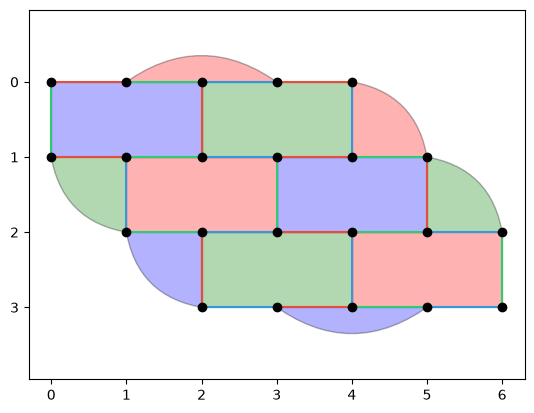

In [5]:
s = CSSHoneycomb()
s.plot_surface()

I want to get boundary plaquettes working now

In [6]:
# NOTE This is complete shit

def colour_plaquette(x):
    """Return the plaquette colour according to its x-coordinate."""
    colours = ("blue", "red", "green")
    return colours[x % 3]


def initialise_boundary_plaquettes(vertices, plaquettes, ncols, nrows):
    """Initialise the plaquettes along the top boundary."""

    vertex_coords = {
        vertex.get_coordinates(): vertex
        for vertex in vertices
    }

    boundary_plaquettes = []

    for x in range(2, ncols - 1, 2):
        vertex = vertex_coords[(x, 0)]

        horizontal_edges = [
            edge
            for edge in vertex.coboundary()
            if edge.get_coordinates()[0][1] == edge.get_coordinates()[1][1]
        ]

        boundary_vertices = list({
            vertex
            for edge in horizontal_edges
            for vertex in edge.boundary()
        })

        boundary_plaquettes.append(
            BoundaryPlaquette(
                len(plaquettes) + len(boundary_plaquettes),
                colour=colour_plaquette(x-1),
                vertices=boundary_vertices,
                flavour="Z",
            )
        )

    return boundary_plaquettes

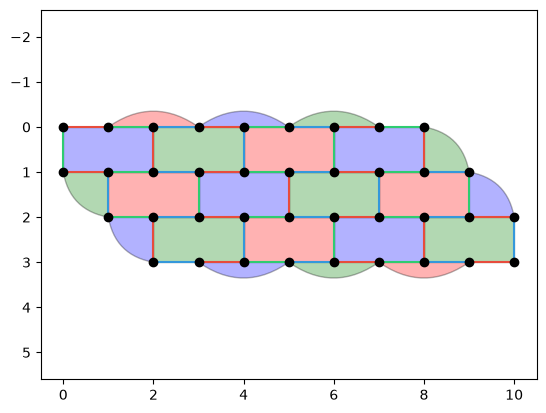

In [7]:
s = CSSHoneycomb(ncols=9)
s.plot_surface()
b = initialise_boundary_plaquettes(s.vertices, s.plaquettes, s.ncols, s.nrows)

In [8]:
print(b[0].get_coordinates())
print(b[1].colour)

((np.float64(1.0), np.float64(0.0)), (np.float64(2.0), np.float64(0.0)), (np.float64(3.0), np.float64(0.0)))
blue


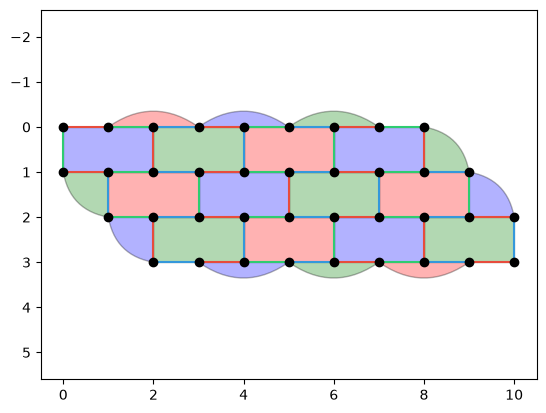

In [9]:
s = CSSHoneycomb(ncols=9)
s.plot_surface()

In [10]:
def colour_plaquette(x):
    """Return the plaquette colour according to its x-coordinate."""
    colours = ("blue", "red", "green")
    return colours[x % 3]


def _make_boundary_plaquette(x, y, vertex_coords, offsets, index, flavour):
    """Build a single boundary plaquette anchored at (x, y).

    Returns None if none of the plaquette's vertices exist in
    `vertex_coords` (i.e. it would be entirely off-grid).
    """
    positions = [(x + dx, y + dy) for dx, dy in offsets]
    candidates = [vertex_coords.get(pos) for pos in positions]

    boundary_vertices = [v for v in candidates if v is not None]
    if not boundary_vertices:
        return None

    missing_positions = [
        pos for pos, v in zip(positions, candidates) if v is None
    ]

    return BoundaryPlaquette(
        index,
        colour=colour_plaquette(x),
        vertices=boundary_vertices,
        missing_positions=missing_positions,
        flavour=flavour,
    )


def initialise_boundary_plaquettes(vertices, plaquettes, ncols, nrows):
    """Initialise the plaquettes along all four boundaries.

    The top/bottom boundaries carry Z-flavoured plaquettes, the
    left/right boundaries carry X-flavoured ones. Each boundary is
    just a list of (x, y) anchor points, so they all share the same
    plaquette-building loop below.
    """

    vertex_coords = {
        vertex.get_coordinates(): vertex
        for vertex in vertices
    }

    offsets = [(0, 0), (1, 0), (2, 0), (2, 1), (1, 1), (0, 1)]

    boundaries = [
        ("Z", [(x, -1) for x in range(1, ncols - 2, 2)]),                       # top
        ("Z", [(x, nrows - 1) for x in range(nrows - 1, ncols + nrows - 4, 2)]),  # bottom
        ("X", [(y - 2, y) for y in range(1, nrows - 1)]),                       # left
        ("X", [(ncols - 1 + y, y) for y in range(0, nrows - 2)]),               # right
    ]

    boundary_plaquettes = []

    for flavour, anchors in boundaries:
        for x, y in anchors:
            plaquette = _make_boundary_plaquette(
                x, y, vertex_coords, offsets,
                index=len(plaquettes) + len(boundary_plaquettes),
                flavour=flavour,
            )
            if plaquette is not None:
                boundary_plaquettes.append(plaquette)

    return boundary_plaquettes

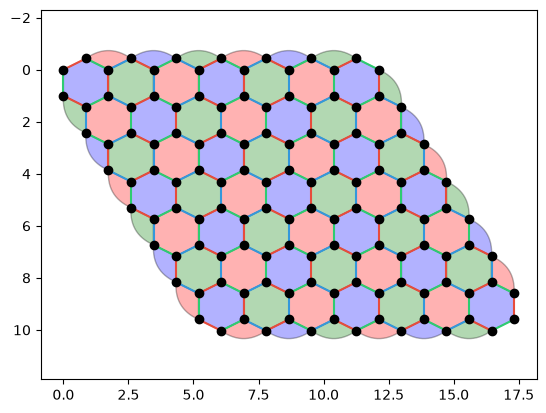

In [11]:
s = CSSHoneycomb(ncols=15, nrows=8)
s.plot_surface(coordinates='hex', savepath="testing/output/surface.png")
b = initialise_boundary_plaquettes(s.vertices, s.plaquettes, s.ncols, s.nrows)